##  STEP 1 : IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')  
sns.set_style("whitegrid")  

## STEP 2:  LOADING THE DATASET

In [2]:
df = pd.read_csv("usedCars.csv")

In [3]:
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


In [4]:
df.shape

(1064, 19)

## STEP 3: Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


In [6]:
df.describe()

,Id,Kilometer,ModelYear,Warranty,QualityScore
count,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000
mean,568156.542293,52807.187970,2016.864662,0.738722,7.770207
std,16438.139974,33840.296979,2.996786,0.439538,0.719717
min,525978.000000,101.000000,2003.000000,0.000000,0.000000
25%,555321.500000,32113.500000,2015.000000,0.000000,7.500000
50%,572753.000000,49432.000000,2017.000000,1.000000,7.800000
75%,583072.750000,68828.500000,2019.000000,1.000000,8.100000
max,589122.000000,640000.000000,2023.000000,1.000000,9.400000


In [7]:
missing = df.isnull().sum()

In [8]:
df["TransmissionType"].fillna("Manual", inplace=True)
df["FuelType"].fillna(df["FuelType"].mode()[0], inplace=True)
df["TransmissionType"].fillna("Manual", inplace=True)
df.drop("CngKit", axis=1, inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

##  STEP 4: DATA VISUALIZATION 

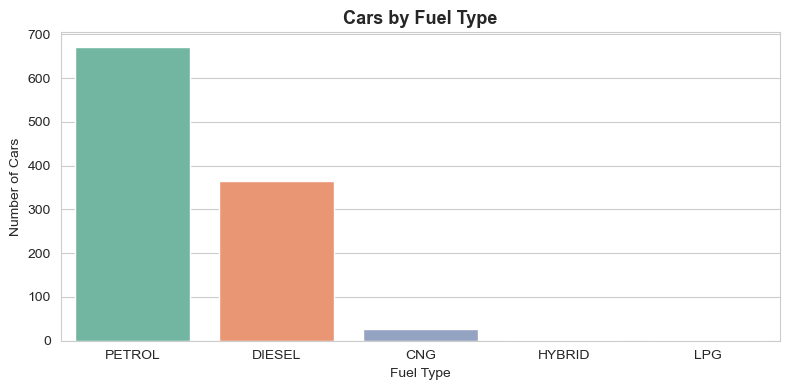

In [10]:
plt.figure(figsize=(8, 4))
fuel_counts = df["FuelType"].value_counts()
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette="Set2")
plt.title("Cars by Fuel Type", fontsize=13, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot02_fuel_type_count.png", dpi=150)
plt.show()

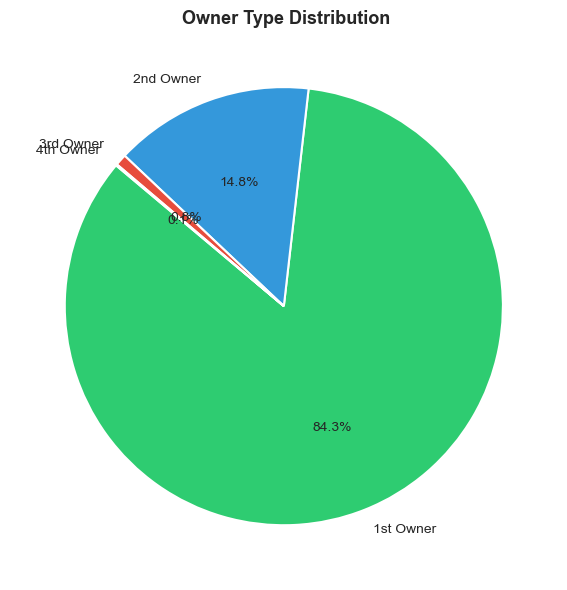

In [11]:
plt.figure(figsize=(6, 6))
owner_counts = df["Owner"].value_counts()
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]
plt.pie(owner_counts.values, labels=owner_counts.index,
        autopct="%1.1f%%", colors=colors, startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title(" Owner Type Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot03_owner_type_pie.png", dpi=150)
plt.show()

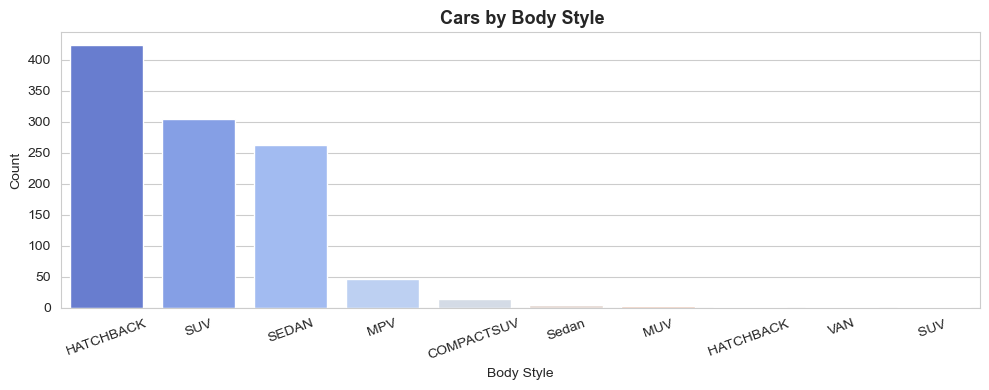

In [12]:
plt.figure(figsize=(10, 4))
body_counts = df["BodyStyle"].value_counts()
sns.barplot(x=body_counts.index, y=body_counts.values, palette="coolwarm")
plt.title(" Cars by Body Style", fontsize=13, fontweight="bold")
plt.xlabel("Body Style")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plot04_body_style_count.png", dpi=150)
plt.show()

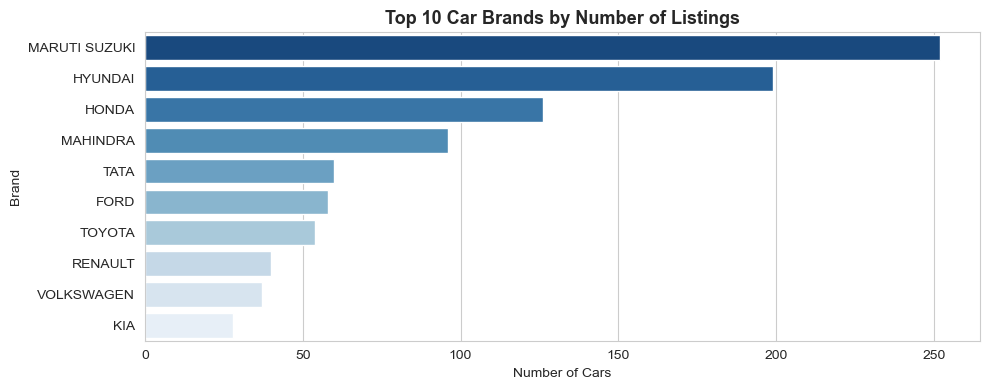

  [Saved] plot05_top_10_brands.png


In [13]:
plt.figure(figsize=(10, 4))
top10_brands = df["Company"].value_counts().head(10)
sns.barplot(x=top10_brands.values, y=top10_brands.index, palette="Blues_r")
plt.title("Top 10 Car Brands by Number of Listings",
          fontsize=13, fontweight="bold")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig("plot05_top_10_brands.png", dpi=150)
plt.show()
print("  [Saved] plot05_top_10_brands.png")

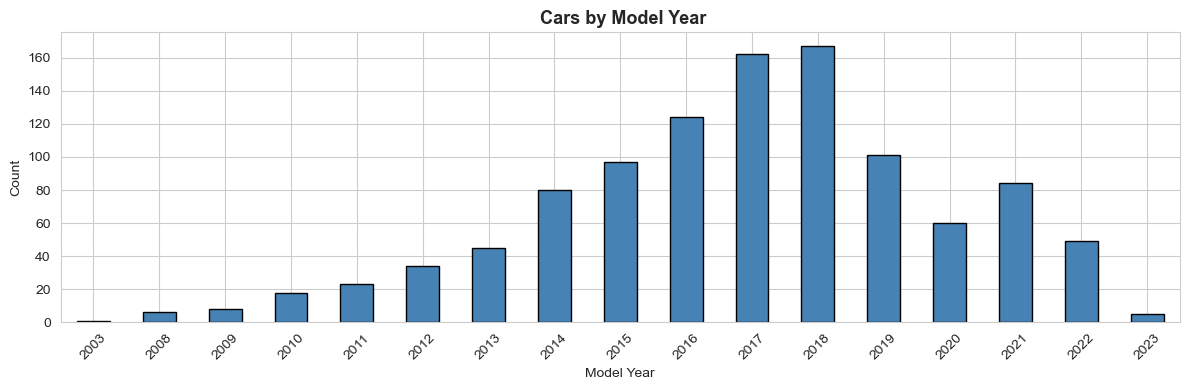

In [14]:
plt.figure(figsize=(12, 4))
df["ModelYear"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="black")
plt.title(" Cars by Model Year", fontsize=13, fontweight="bold")
plt.xlabel("Model Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot06_model_year.png", dpi=150)
plt.show()

In [15]:
df_viz = df.copy()
df_viz["Price_num"] = (
    df_viz["Price"]
    .str.replace(" Lakhs", "", regex=False)  
    .str.replace(",", "", regex=False)        
    .astype(float)
)
df_viz["CarAge"] = 2024 - df_viz["ModelYear"]

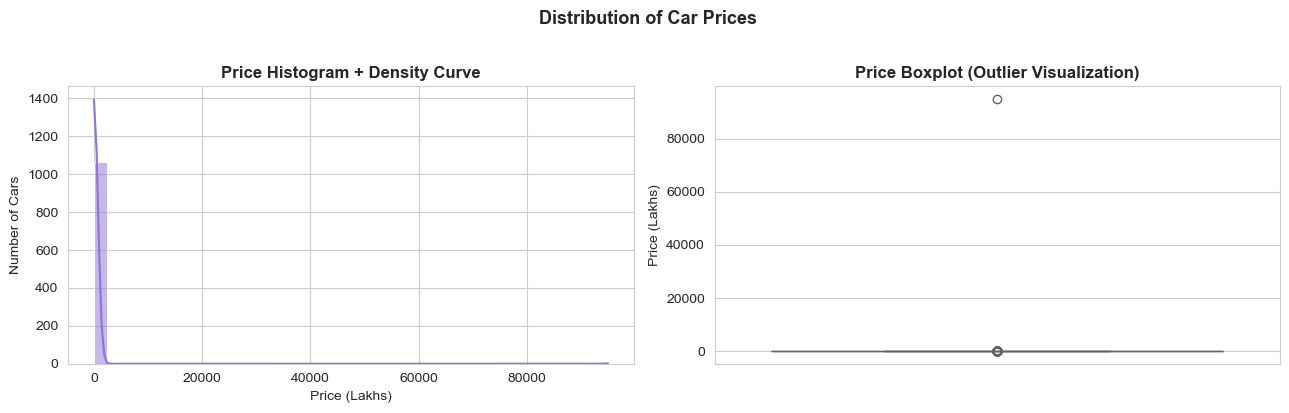

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_viz["Price_num"], bins=40, kde=True,
             color="mediumpurple", ax=axes[0])
axes[0].set_title("Price Histogram + Density Curve", fontweight="bold")
axes[0].set_xlabel("Price (Lakhs)")
axes[0].set_ylabel("Number of Cars")
sns.boxplot(y=df_viz["Price_num"], color="mediumpurple", ax=axes[1])
axes[1].set_title("Price Boxplot (Outlier Visualization)", fontweight="bold")
axes[1].set_ylabel("Price (Lakhs)")
plt.suptitle(" Distribution of Car Prices",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot07_price_distribution.png", dpi=150)
plt.show()

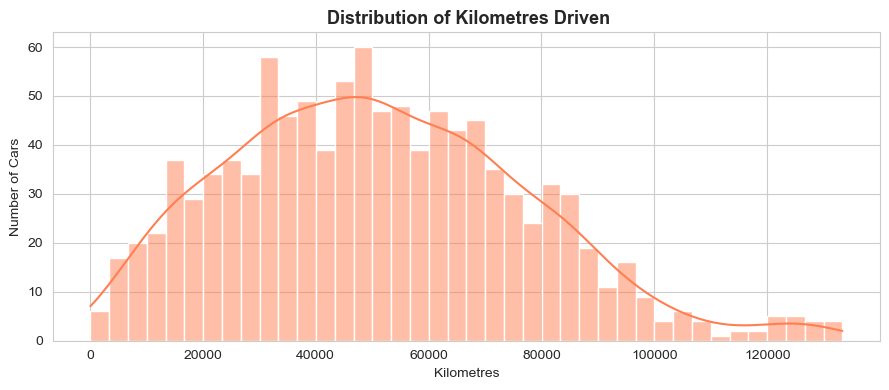

In [17]:
km_plot = df_viz[df_viz["Kilometer"] < df_viz["Kilometer"].quantile(0.99)]["Kilometer"]
plt.figure(figsize=(9, 4))
sns.histplot(km_plot, bins=40, kde=True, color="coral")
plt.title(" Distribution of Kilometres Driven",
          fontsize=13, fontweight="bold")
plt.xlabel("Kilometres")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.savefig("plot08_km_distribution.png", dpi=150)
plt.show()

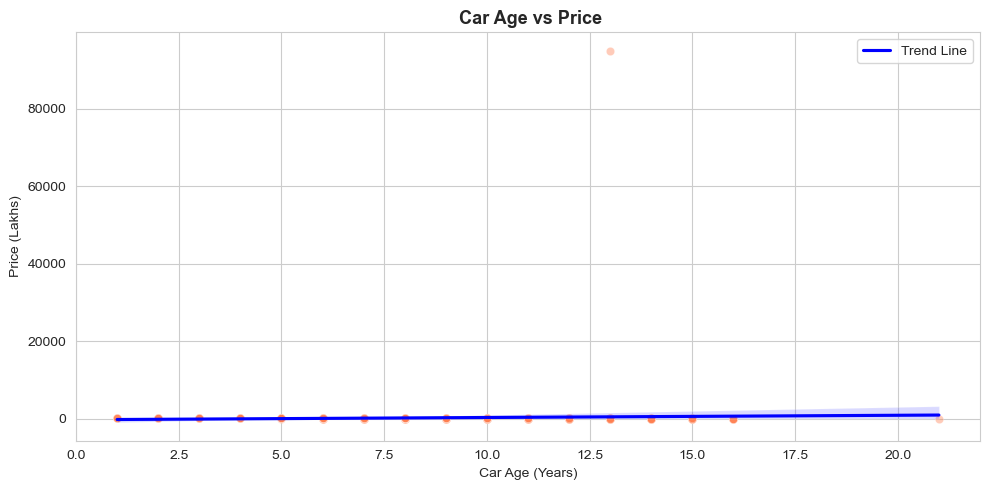

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_viz, x="CarAge", y="Price_num",
                alpha=0.4, color="coral")
sns.regplot(data=df_viz, x="CarAge", y="Price_num",
            scatter=False, color="blue", label="Trend Line")
plt.title(" Car Age vs Price", fontsize=13, fontweight="bold")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price (Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig("plot09_age_vs_price.png", dpi=150)
plt.show()

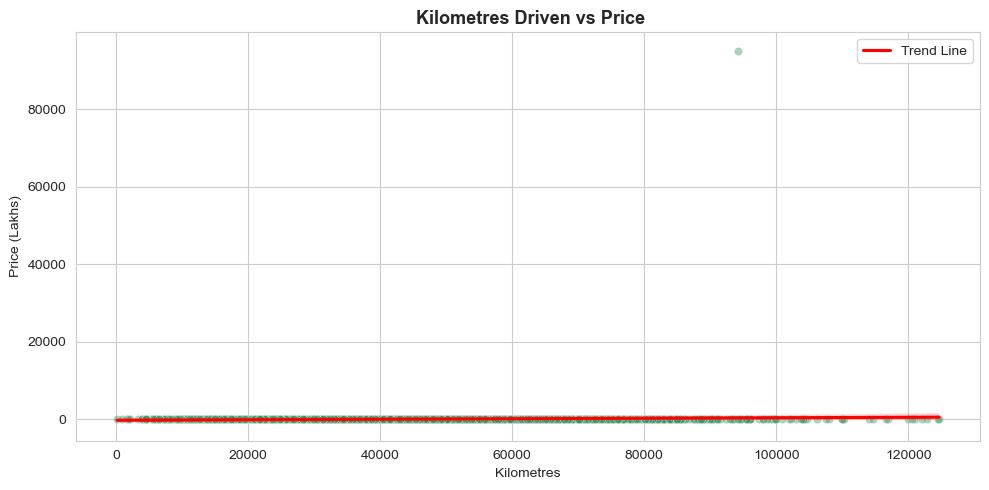

In [19]:
km_cap_viz = df_viz[df_viz["Kilometer"] < df_viz["Kilometer"].quantile(0.98)]
plt.figure(figsize=(10, 5))
sns.scatterplot(data=km_cap_viz, x="Kilometer", y="Price_num",
                alpha=0.4, color="seagreen")
sns.regplot(data=km_cap_viz, x="Kilometer", y="Price_num",
            scatter=False, color="red", label="Trend Line")
plt.title(" Kilometres Driven vs Price", fontsize=13, fontweight="bold")
plt.xlabel("Kilometres")
plt.ylabel("Price (Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig("plot10_km_vs_price.png", dpi=150)
plt.show()

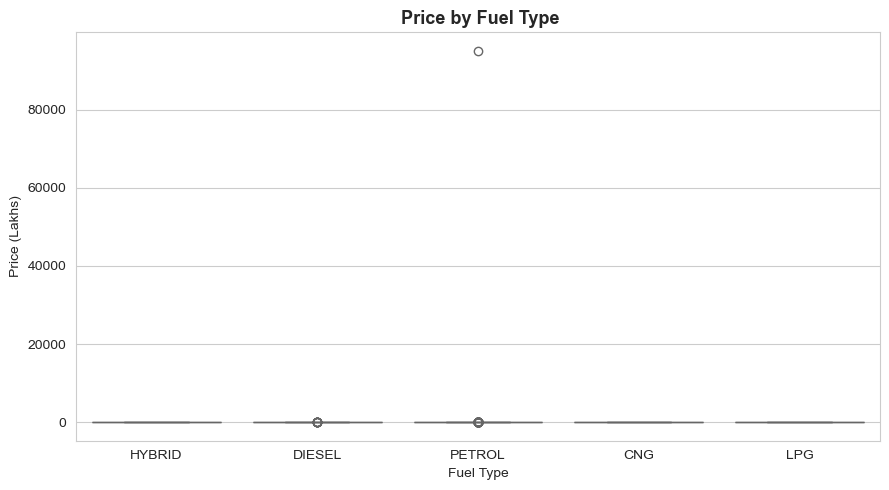

In [20]:
plt.figure(figsize=(9, 5))
fuel_order = (df_viz.groupby("FuelType")["Price_num"]
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df_viz, x="FuelType", y="Price_num",
            order=fuel_order, palette="Set3")
plt.title(" Price by Fuel Type", fontsize=13, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Price (Lakhs)")
plt.tight_layout()
plt.savefig("plot11_fuel_vs_price.png", dpi=150)
plt.show()



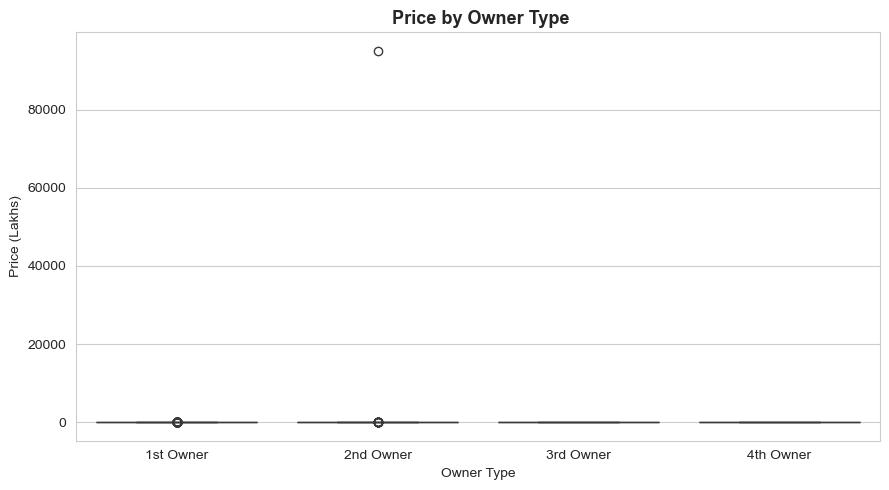

In [21]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_viz, x="Owner", y="Price_num",
            order=["1st Owner", "2nd Owner", "3rd Owner", "4th Owner"],
            palette="Blues")
plt.title(" Price by Owner Type", fontsize=13, fontweight="bold")
plt.xlabel("Owner Type")
plt.ylabel("Price (Lakhs)")
plt.tight_layout()
plt.savefig("plot12_owner_vs_price.png", dpi=150)
plt.show()

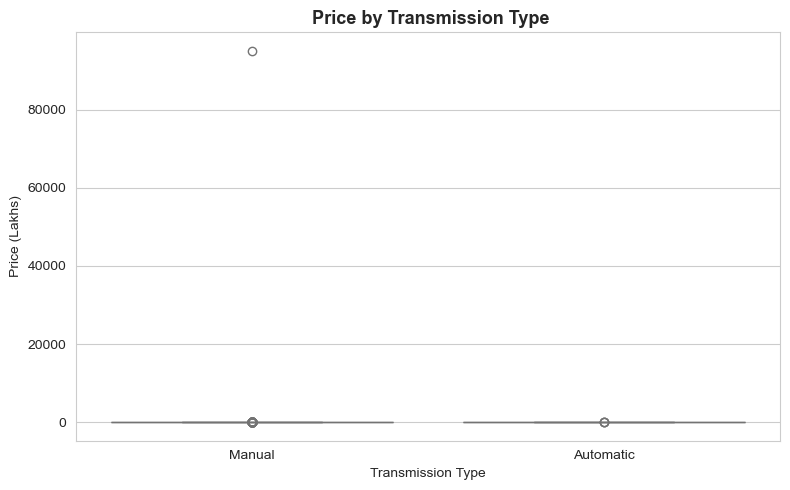

In [22]:
df_viz["Trans_clean"] = df_viz["TransmissionType"].apply(
    lambda x: "Automatic"
    if str(x).upper().strip() in ["AUTOMATIC", "AUOTMATIC", "A", "CVT"]
    else "Manual"
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_viz, x="Trans_clean", y="Price_num", palette="pastel")
plt.title(" Price by Transmission Type", fontsize=13, fontweight="bold")
plt.xlabel("Transmission Type")
plt.ylabel("Price (Lakhs)")
plt.tight_layout()
plt.savefig("plot13_transmission_vs_price.png", dpi=150)
plt.show()

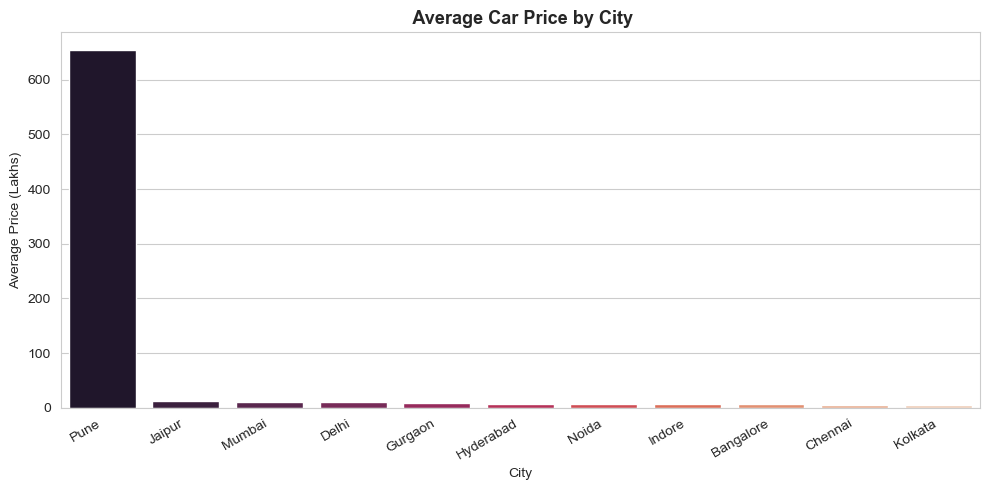

In [23]:
plt.figure(figsize=(10, 5))
avg_city = (df_viz.groupby("City")["Price_num"]
            .mean().sort_values(ascending=False))
sns.barplot(x=avg_city.index, y=avg_city.values, palette="rocket")
plt.title(" Average Car Price by City", fontsize=13, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plot14_city_vs_price.png", dpi=150)
plt.show()

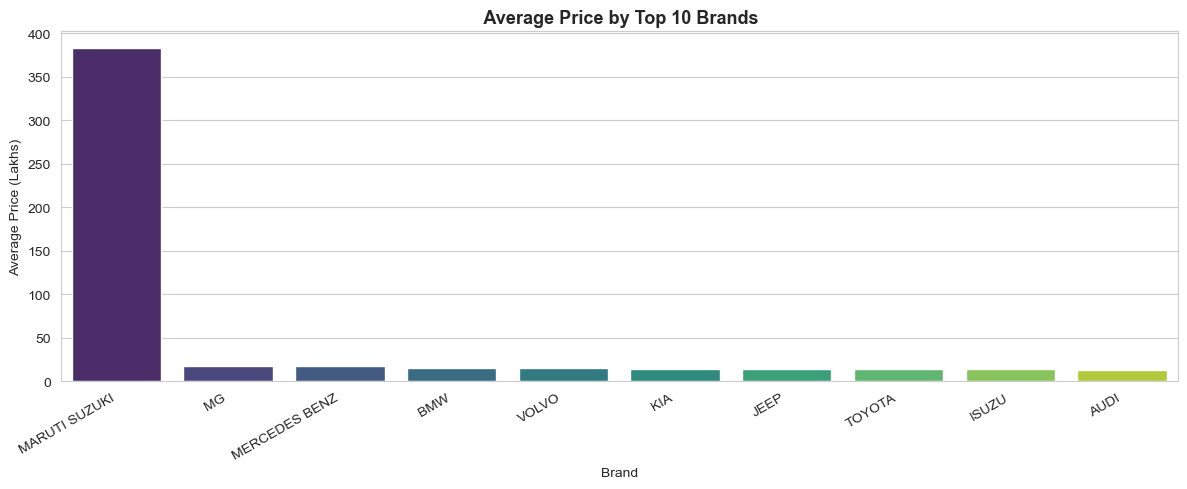

In [24]:
plt.figure(figsize=(12, 5))
avg_brand = (df_viz.groupby("Company")["Price_num"]
             .mean().sort_values(ascending=False).head(10))
sns.barplot(x=avg_brand.index, y=avg_brand.values, palette="viridis")
plt.title(" Average Price by Top 10 Brands",
          fontsize=13, fontweight="bold")
plt.xlabel("Brand")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plot15_brand_vs_price.png", dpi=150)
plt.show()

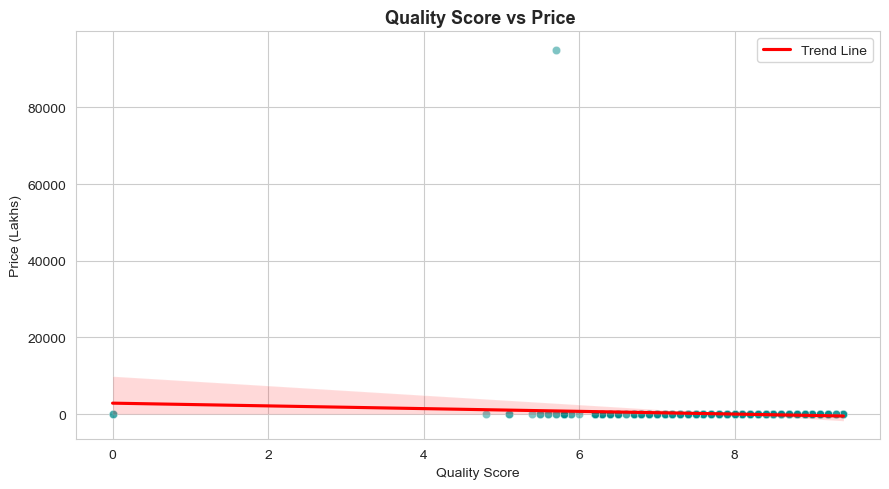

In [25]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_viz, x="QualityScore", y="Price_num",
                alpha=0.5, color="darkcyan")
sns.regplot(data=df_viz, x="QualityScore", y="Price_num",
            scatter=False, color="red", label="Trend Line")
plt.title(" Quality Score vs Price", fontsize=13, fontweight="bold")
plt.xlabel("Quality Score")
plt.ylabel("Price (Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig("plot16_quality_vs_price.png", dpi=150)
plt.show()

## STEP 5 : DATA PREPROCESSING 

In [26]:
data = df.copy()

In [27]:
data["Price"] = data["Price"].astype(str)
data["Price"] = data["Price"].str.replace(" Lakhs", "", regex=False)
data["Price"] = data["Price"].str.replace(",", "", regex=False)
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")
print("Missing after conversion:", data["Price"].isnull().sum())
print(f"\n Price parsed to float successfully.")
print(f"Price Range : Rs.{data['Price'].min()} Lakhs to Rs.{data['Price'].max()} Lakhs")


Missing after conversion: 0

 Price parsed to float successfully.
Price Range : Rs.1.0 Lakhs to Rs.95000.0 Lakhs


In [28]:
def clean_transmission(val):
    if pd.isnull(val):
        return "Manual"                        
    v = str(val).strip().upper()
    if v in ["AUTOMATIC", "AUOTMATIC", "A", "CVT"]:
        return "Automatic"
    return "Manual"                            

data["TransmissionType"] = data["TransmissionType"].apply(clean_transmission)
print(f"\n TransmissionType standardized.")
print(f"  Unique values now : {data['TransmissionType'].unique()}")



 TransmissionType standardized.
  Unique values now : ['Manual' 'Automatic']


In [29]:
fuel_mode = data["FuelType"].mode()[0]
data["FuelType"].fillna(fuel_mode, inplace=True)
print(f"\n FuelType : missing value filled with mode - '{fuel_mode}'")


 FuelType : missing value filled with mode - 'PETROL'


In [30]:
data.drop(columns=["Id", "DealerName", "Variant", "ManufactureDate"],
          inplace=True)
print("\n Dropped columns : Id, DealerName, Variant, ManufactureDate")


 Dropped columns : Id, DealerName, Variant, ManufactureDate


In [31]:
km_99 = data["Kilometer"].quantile(0.99)
data["Kilometer"] = data["Kilometer"].clip(upper=km_99)
print(f"\n Kilometre outliers capped at {km_99:,.0f} km (99th percentile)")


 Kilometre outliers capped at 134,825 km (99th percentile)


## STEP 6 : FEATURE ENGINEERING

In [32]:
data["CarAge"] = 2024 - data["ModelYear"]
print(f"\n'CarAge' feature created  (2024 - ModelYear)")
print(f"  Range : {data['CarAge'].min()} years  to  {data['CarAge'].max()} years")
owner_map          = {"1st Owner": 1, "2nd Owner": 2, "3rd Owner": 3, "4th Owner": 4}
data["OwnerScore"] = data["Owner"].map(owner_map)
print("\n 'OwnerScore' feature created")
print("  Mapping : 1st Owner=1 , 2nd Owner=2 , 3rd Owner=3 , 4th Owner=4")
print("\nSample of dataset with new features :")
print(data[["ModelYear", "CarAge", "Owner", "OwnerScore", "Kilometer", "Price"]].head(6))


'CarAge' feature created  (2024 - ModelYear)
  Range : 1 years  to  21 years

 'OwnerScore' feature created
  Mapping : 1st Owner=1 , 2nd Owner=2 , 3rd Owner=3 , 4th Owner=4

Sample of dataset with new features :
   ModelYear  CarAge      Owner  OwnerScore  Kilometer  Price
0       2018       6  1st Owner           1    33197.0   5.75
1       2021       3  1st Owner           1    10322.0   4.35
2       2015       9  1st Owner           1    37889.0   4.70
3       2020       4  1st Owner           1    13106.0   9.90
4       2010      14  2nd Owner           2   104614.0   2.70
5       2013      11  3rd Owner           3    87700.0   9.99


## STEP 7 : ENCODING CATEGORICAL VARIABLES

In [33]:
categorical_cols = [
    "FuelType",
    "BodyStyle",
    "TransmissionType",
    "Company",
    "City",
    "DealerState"
]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    print(f"{col:22s} --> encoded ({len(le.classes_)} unique categories)")

print("\nAll categorical columns successfully converted to numbers.")

FuelType               --> encoded (5 unique categories)
BodyStyle              --> encoded (10 unique categories)
TransmissionType       --> encoded (2 unique categories)
Company                --> encoded (23 unique categories)
City                   --> encoded (11 unique categories)
DealerState            --> encoded (10 unique categories)

All categorical columns successfully converted to numbers.


## STEP  8 : FEATURE SELECTION

In [34]:
FEATURES = [
    "Kilometer",          
    "CarAge",             
    "OwnerScore",        
    "Warranty",          
    "QualityScore",      
    "FuelType",          
    "BodyStyle",         
    "TransmissionType",   
    "Company",            
    "City",             
    "DealerState",       
]
TARGET = "Price"
X = data[FEATURES]
y = data[TARGET]
print(f"\n  Total Features Selected : {len(FEATURES)}")
print(f"  Target Variable         : {TARGET}")
print(f"  Total Usable Samples    : {len(X)}")

print("\n  Features List :")
for i, f in enumerate(FEATURES, 1):
    print(f"    {i:2d}. {f}")


  Total Features Selected : 11
  Target Variable         : Price
  Total Usable Samples    : 1064

  Features List :
     1. Kilometer
     2. CarAge
     3. OwnerScore
     4. Warranty
     5. QualityScore
     6. FuelType
     7. BodyStyle
     8. TransmissionType
     9. Company
    10. City
    11. DealerState


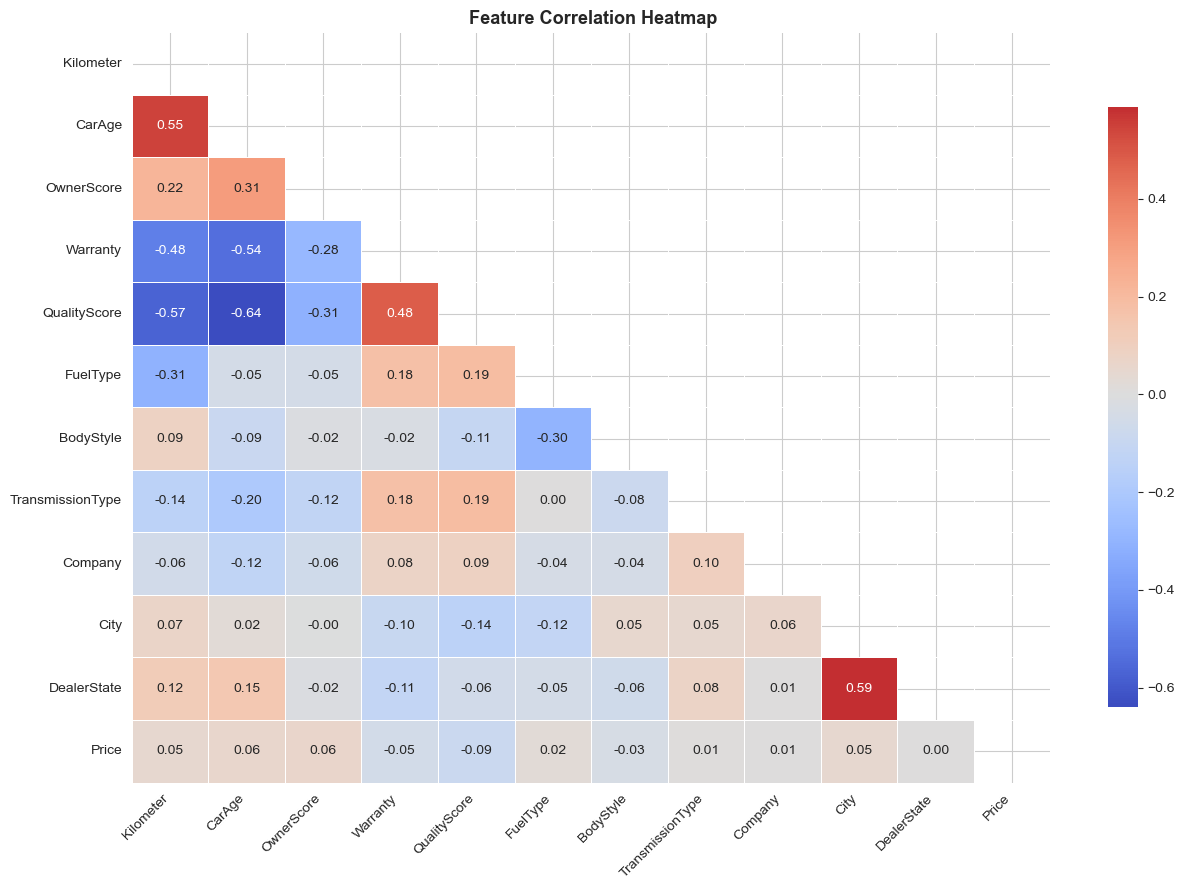


  Correlation of Each Feature with Price (sorted) :
OwnerScore          0.063270
CarAge              0.059213
City                0.048068
Kilometer           0.047051
FuelType            0.022785
TransmissionType    0.007140
Company             0.005949
DealerState         0.004851
BodyStyle          -0.033561
Warranty           -0.051338
QualityScore       -0.087956


In [35]:
plt.figure(figsize=(13, 9))
corr_matrix = pd.concat([X, y], axis=1).corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title(" Feature Correlation Heatmap",
          fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot17_correlation_heatmap.png", dpi=150)
plt.show()
print("\n  Correlation of Each Feature with Price (sorted) :")
corr_price = pd.concat([X, y], axis=1).corr()[TARGET].drop(TARGET)
print(corr_price.sort_values(ascending=False).to_string())



## STEP 9 : TRAIN / TEST SPLIT AND FEATURE SCALING

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"\n  Training Set Size : {len(X_train)} cars  (80%)")
print(f"  Test Set Size     : {len(X_test)} cars  (20%)")
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   
X_test_sc  = scaler.transform(X_test)
print("\n  StandardScaler applied successfully.")
print("  All features now have mean = 0 and standard deviation = 1.")


  Training Set Size : 851 cars  (80%)
  Test Set Size     : 213 cars  (20%)

  StandardScaler applied successfully.
  All features now have mean = 0 and standard deviation = 1.


## STEP 10 : MODEL BUILDING  (Random Forest Regressor)

In [37]:
rf_model = RandomForestRegressor(
    n_estimators      = 200,
    max_depth         = 12,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    random_state      = 42,
    n_jobs            = -1
)
print("\n  Training Random Forest with 200 trees. Please wait ...")
rf_model.fit(X_train, y_train)
print("  Model training complete!")
cv_r2 = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
print(f"\n  5-Fold Cross-Validation Results :")
print(f"  R2 Scores per fold : {cv_r2.round(4)}")
print(f"  Mean R2            : {cv_r2.mean():.4f}")
print(f"  Std Deviation      : {cv_r2.std():.4f}")
print("  (Consistent scores across all 5 folds = model generalizes well)")


  Training Random Forest with 200 trees. Please wait ...
  Model training complete!

  5-Fold Cross-Validation Results :
  R2 Scores per fold : [-2.03228784e+05 -4.90000000e-03  3.18800000e-01 -7.65603026e+04
  5.72400000e-01]
  Mean R2            : -55957.6401
  Std Deviation      : 79381.5234
  (Consistent scores across all 5 folds = model generalizes well)


## STEP 11 : MODEL EVALUATION

In [38]:
y_pred = rf_model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
results_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})
print("\nModel Evaluation Table:")
print(results_df)


Model Evaluation Table:
     Metric         Value
0       MAE  1.004588e+02
1       MSE  1.015724e+06
2      RMSE  1.007831e+03
3  R2 Score -4.245471e+04


## STEP 12 : RESULT VISUALIZATIONS

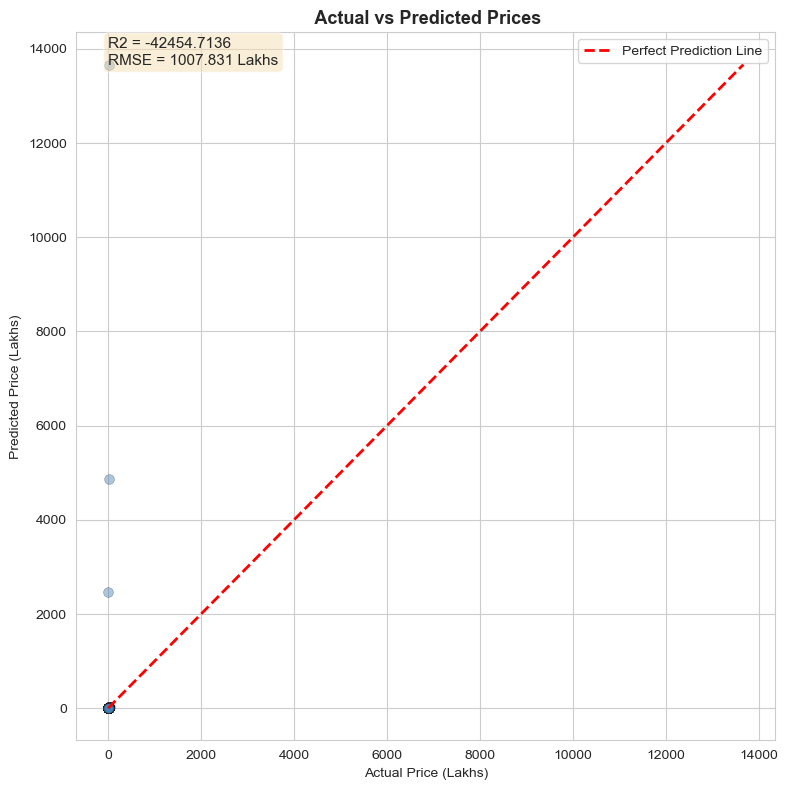

In [39]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.45, color="steelblue",
            edgecolors="black", linewidths=0.3, s=50)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect Prediction Line")
info_box = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
plt.text(lo + 0.5, hi - 3.5,
         f"R2 = {r2:.4f}\nRMSE = {rmse:.3f} Lakhs",
         fontsize=11, bbox=info_box)
plt.title(" Actual vs Predicted Prices",
          fontsize=13, fontweight="bold")
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig("plot18_actual_vs_predicted.png", dpi=150)
plt.show()


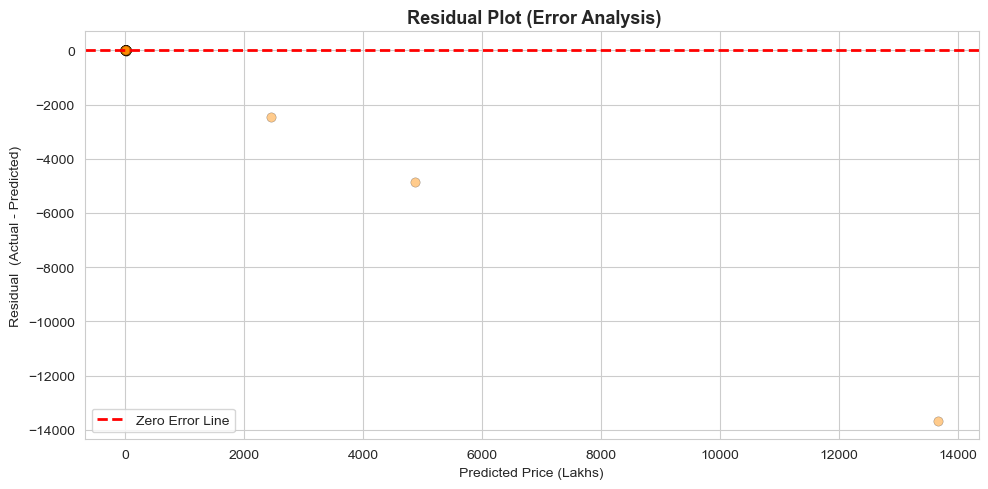

In [40]:
residuals = y_test.values - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.45, color="darkorange",
            edgecolors="black", linewidths=0.3, s=45)
plt.axhline(0, color="red", linestyle="--", lw=2, label="Zero Error Line")
plt.title(" Residual Plot (Error Analysis)",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residual  (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.savefig("plot19_residual_plot.png", dpi=150)
plt.show()

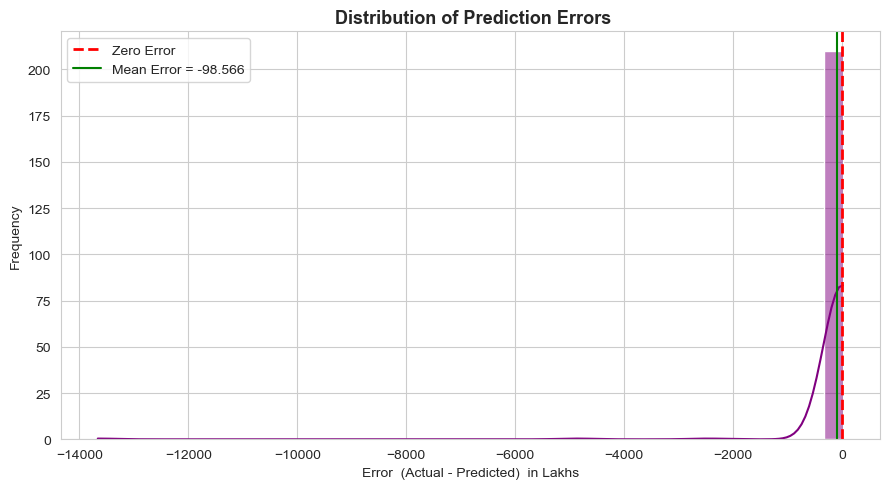

In [41]:
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=40, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--", lw=2, label="Zero Error")
plt.axvline(residuals.mean(), color="green", linestyle="-", lw=1.5,
            label=f"Mean Error = {residuals.mean():.3f}")
plt.title(" Distribution of Prediction Errors",
          fontsize=13, fontweight="bold")
plt.xlabel("Error  (Actual - Predicted)  in Lakhs")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("plot20_residual_distribution.png", dpi=150)
plt.show()

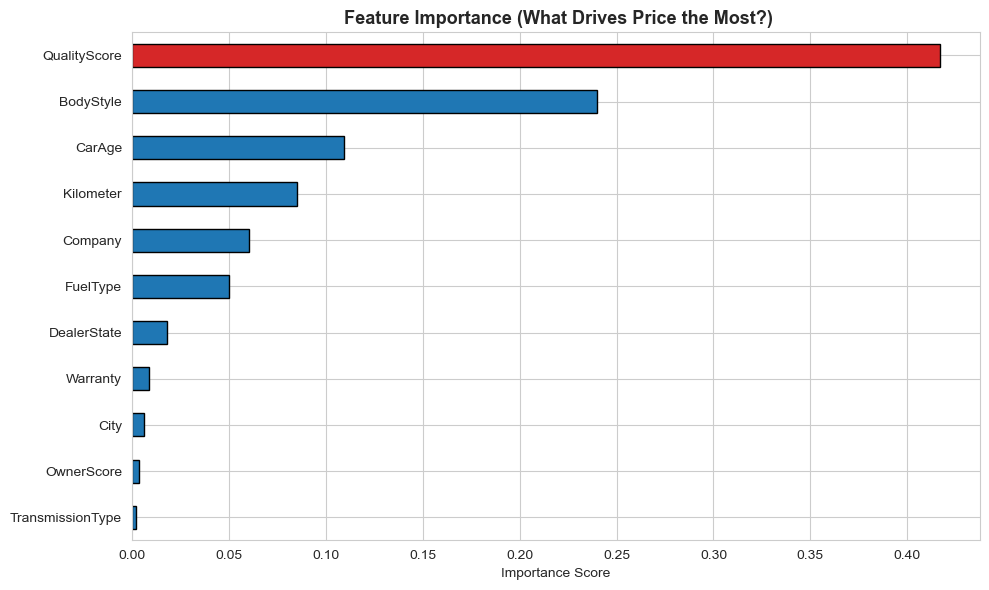


  Most Important Feature : QualityScore  (Score = 0.4166)


In [42]:
feat_imp   = pd.Series(rf_model.feature_importances_,
                        index=FEATURES).sort_values(ascending=True)
bar_colors = ["#d62728" if f == feat_imp.idxmax()
               else "#1f77b4" for f in feat_imp.index]
plt.figure(figsize=(10, 6))
feat_imp.plot(kind="barh", color=bar_colors, edgecolor="black")
plt.title(" Feature Importance (What Drives Price the Most?)",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot21_feature_importance.png", dpi=150)
plt.show()
print(f"\n  Most Important Feature : {feat_imp.idxmax()}"
      f"  (Score = {feat_imp.max():.4f})")

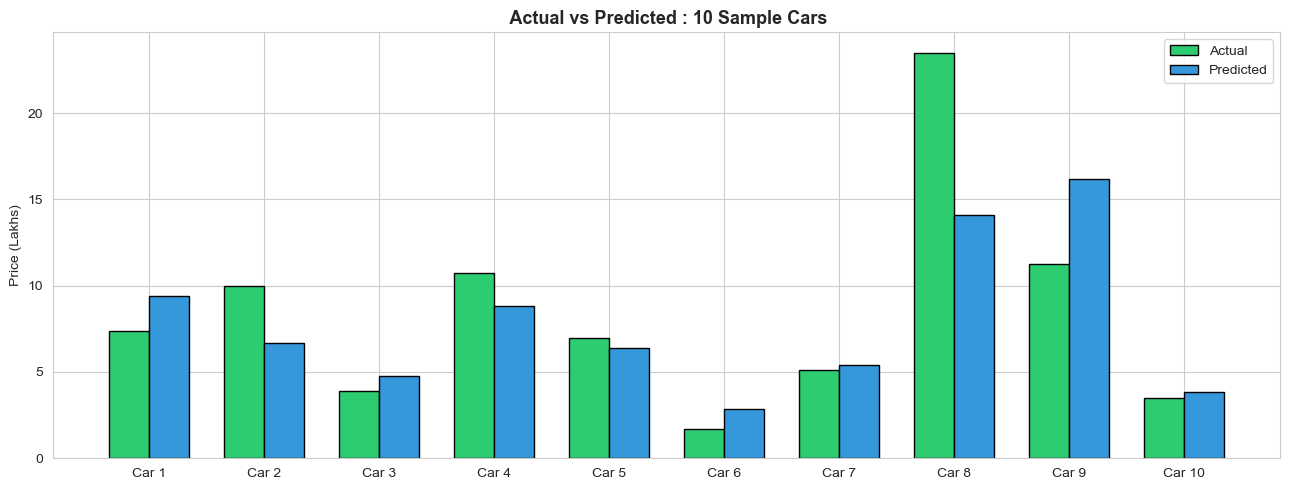

In [43]:
np.random.seed(7)
idx10  = np.random.choice(len(X_test), 10, replace=False)
act10  = y_test.iloc[idx10].values.round(2)
pred10 = rf_model.predict(X_test.iloc[idx10]).round(2)
labels = [f"Car {i+1}" for i in range(10)]
x_pos  = np.arange(10)
w      = 0.35
plt.figure(figsize=(13, 5))
plt.bar(x_pos - w/2, act10,  w, label="Actual",    color="#2ecc71", edgecolor="black")
plt.bar(x_pos + w/2, pred10, w, label="Predicted", color="#3498db", edgecolor="black")
plt.xticks(x_pos, labels)
plt.title(" Actual vs Predicted : 10 Sample Cars",
          fontsize=13, fontweight="bold")
plt.ylabel("Price (Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig("plot22_sample_bar_comparison.png", dpi=150)
plt.show()

## STEP 13 : SAMPLE PREDICTIONS TABLE

In [44]:
np.random.seed(10)
s_idx  = np.random.choice(len(X_test), 12, replace=False)
s_act  = y_test.iloc[s_idx].values
s_pred = rf_model.predict(X_test.iloc[s_idx])

sample_table = pd.DataFrame({
    "Actual Price (Lakhs)"    : s_act.round(2),
    "Predicted Price (Lakhs)" : s_pred.round(2),
    "Difference (Lakhs)"      : (s_act - s_pred).round(2),
    "Error Percentage"        : (abs(s_act - s_pred) / s_act * 100).round(1)
})

print("\n  Sample Predictions vs Actual Prices :\n")
print(sample_table.to_string(index=False))


  Sample Predictions vs Actual Prices :

 Actual Price (Lakhs)  Predicted Price (Lakhs)  Difference (Lakhs)  Error Percentage
                 8.00                     7.66                0.34               4.3
                 7.50                     7.24                0.26               3.4
                 8.25                    17.96               -9.71             117.8
                 6.50                     7.20               -0.70              10.8
                 5.35                     6.92               -1.57              29.4
                 7.15                     6.87                0.28               4.0
                12.50                    14.15               -1.65              13.2
                11.50                    11.14                0.36               3.1
                 6.93                    12.29               -5.36              77.4
                12.50                     9.74                2.76              22.0
                 1.67  

## STEP 14 : PROJECT SUMMARY

In [46]:
top3 = feat_imp.sort_values(ascending=False).index[:3].tolist()

print(f"""
  DATASET
  -------
  Source         : usedCars.csv
  Total Records  : 1064 used car listings
  Total Columns  : 19 (after loading)
  Target Variable: Price (in Indian Rupees, Lakhs)
  Cities Covered : Major Indian metro cities

  DATA PREPROCESSING COMPLETED
  ----------------------------
  [1] Price parsed from "X.XX Lakhs" string format to float
  [2] TransmissionType : 10 inconsistent labels cleaned to 2 (Manual/Automatic)
  [3] FuelType : 1 missing value filled using mode imputation
  [4] CngKit column dropped (98% of values were missing)
  [5] Dropped columns : Id, DealerName, Variant, ManufactureDate
  [6] Kilometre outliers capped at 99th percentile to remove extremes

  FEATURE ENGINEERING
  -------------------
  [1] CarAge    = 2024 - ModelYear  (converts year to age in years)
  [2] OwnerScore = 1 to 4  (converts owner type text to numeric scale)
  [3] Label Encoding applied to 6 categorical columns

  FEATURES USED IN MODEL
  ----------------------
  {', '.join(FEATURES)}

  ALGORITHM
  ---------
  Model         : Random Forest Regressor
  Trees Built   : 200
  Max Depth     : 12
  Cross-Validation : 5-Fold  (Mean R2 = {cv_r2.mean():.4f})

  FINAL MODEL PERFORMANCE
  -----------------------
  MAE  (Mean Absolute Error)  :  {mae:.4f} Lakhs
  MSE  (Mean Squared Error)   :  {mse:.4f}
  RMSE (Root Mean Sq. Error)  :  {rmse:.4f} Lakhs
  R2   Score                  :  {r2:.4f}  ({r2*100:.1f}%)

""")


  DATASET
  -------
  Source         : usedCars.csv
  Total Records  : 1064 used car listings
  Total Columns  : 19 (after loading)
  Target Variable: Price (in Indian Rupees, Lakhs)
  Cities Covered : Major Indian metro cities

  DATA PREPROCESSING COMPLETED
  ----------------------------
  [1] Price parsed from "X.XX Lakhs" string format to float
  [2] TransmissionType : 10 inconsistent labels cleaned to 2 (Manual/Automatic)
  [3] FuelType : 1 missing value filled using mode imputation
  [4] CngKit column dropped (98% of values were missing)
  [5] Dropped columns : Id, DealerName, Variant, ManufactureDate
  [6] Kilometre outliers capped at 99th percentile to remove extremes

  FEATURE ENGINEERING
  -------------------
  [1] CarAge    = 2024 - ModelYear  (converts year to age in years)
  [2] OwnerScore = 1 to 4  (converts owner type text to numeric scale)
  [3] Label Encoding applied to 6 categorical columns

  FEATURES USED IN MODEL
  ----------------------
  Kilometer, CarAge, Owne